In [20]:
import numpy as np
import lmt_sim.lmt_simulation as sim
import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
import version_info as vs

i_lmt = 4
atom_radius = 0.0
beam_waist = 5e-3
initial_velocity_z = 0.0
detuning_hz = sim.RECOIL_FREQUENCY_HZ


# Single $\pi$ pulse

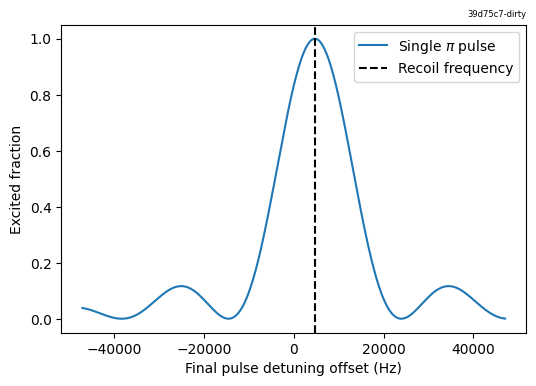

In [21]:
detunings_hz  = np.linspace(-10.0, 10.0, 501) * sim.RECOIL_FREQUENCY_HZ

plt.figure(figsize=(6, 4))



m, positions, velocities, amplitudes, internal_is_ground = sim.make_atom_states(
    position_x=atom_radius,
    position_y=0.0,
    position_z=0.0,
    initial_velocity_z=initial_velocity_z,
    c0=1.0,
    c1=0.0,
)

laser_direction = +1

excited_scan = []
for detuning_offset_hz in detunings_hz:
    detuning_hz = detuning_offset_hz

    m_trial = m.copy()
    positions_trial = positions.copy()
    velocities_trial = velocities.copy()
    amplitudes_trial = amplitudes.copy()
    internal_is_ground_trial = internal_is_ground.copy()

    pulse = seq.Pulse(
        k=laser_direction,
        detuning_hz=detuning_hz,
        phi=0.0,
        label="$\\pi$ pulse",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    )

    result = seq.run_pulse_sequence_in_lab_frame(
        m_trial,
        positions_trial,
        velocities_trial,
        amplitudes_trial,
        internal_is_ground_trial,
        pulse_sequence=[pulse],
    )

    if result is None:
        raise RuntimeError("Atom was cleared out by final pulse")

    (
        m_trial,
        positions_trial,
        velocities_trial,
        amplitudes_trial,
        internal_is_ground_trial,
        _,
        _,
    ) = result

    ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(
        m_trial, amplitudes_trial, internal_is_ground_trial
    )
    excited_scan.append(excited_prob / (ground_prob + excited_prob))

plt.plot(
    detunings_hz,
    excited_scan,
    label="Single $\\pi$ pulse"
)


plt.xlabel("Final pulse detuning offset (Hz)")
plt.ylabel("Excited fraction")
plt.axvline(sim.RECOIL_FREQUENCY_HZ, color="k", linestyle="--", label="Recoil frequency")
plt.legend()

# plt.xlim([-1000, 1000])

vs.tag_plot(small=True);

# $\pi$ up then $\pi$ down

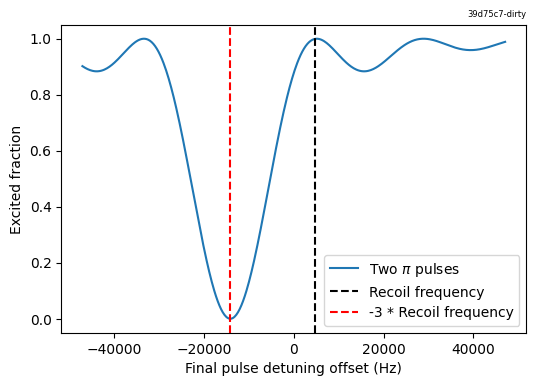

In [22]:
detunings_hz  = np.linspace(-10.0, 10.0, 501) * sim.RECOIL_FREQUENCY_HZ

plt.figure(figsize=(6, 4))

m, positions, velocities, amplitudes, internal_is_ground = sim.make_atom_states(
    position_x=atom_radius,
    position_y=0.0,
    position_z=0.0,
    initial_velocity_z=initial_velocity_z,
    c0=1.0,
    c1=0.0,
)



excited_scan = []
for detuning_offset_hz in detunings_hz:
    detuning_hz = detuning_offset_hz

    m_trial = m.copy()
    positions_trial = positions.copy()
    velocities_trial = velocities.copy()
    amplitudes_trial = amplitudes.copy()
    internal_is_ground_trial = internal_is_ground.copy()

    pulse_1 = seq.Pulse(
        k=+1,
        detuning_hz=sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="$\\pi$ pulse",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    )
    pulse_2 = seq.Pulse(
        k=-1,
        detuning_hz=detuning_hz,
        phi=0.0,
        label="$\\pi$ pulse",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    )

    result = seq.run_pulse_sequence_in_lab_frame(
        m_trial,
        positions_trial,
        velocities_trial,
        amplitudes_trial,
        internal_is_ground_trial,
        pulse_sequence=[pulse_1, pulse_2],
    )

    if result is None:
        raise RuntimeError("Atom was cleared out by final pulse")

    (
        m_trial,
        positions_trial,
        velocities_trial,
        amplitudes_trial,
        internal_is_ground_trial,
        _,
        _,
    ) = result

    ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(
        m_trial, amplitudes_trial, internal_is_ground_trial
    )
    excited_scan.append(excited_prob / (ground_prob + excited_prob))

plt.plot(
    detunings_hz,
    excited_scan,
    label="Two $\\pi$ pulses"
)


plt.xlabel("Final pulse detuning offset (Hz)")
plt.ylabel("Excited fraction")
plt.axvline(sim.RECOIL_FREQUENCY_HZ, color="k", linestyle="--", label="Recoil frequency")
plt.axvline(-3*sim.RECOIL_FREQUENCY_HZ, color="r", linestyle="--", label="-3 * Recoil frequency")
plt.legend()

# plt.xlim([-1000, 1000])

vs.tag_plot(small=True);

# $\pi$ up, $\pi$ down, $\pi$ up

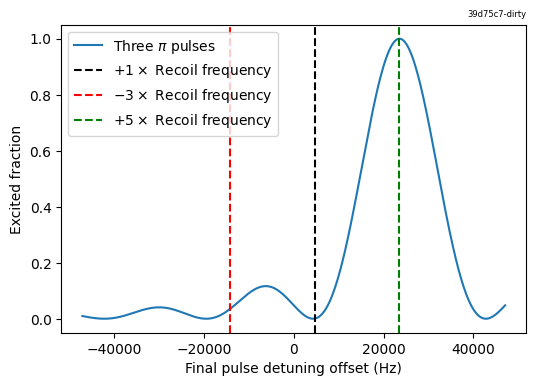

In [23]:
detunings_hz  = np.linspace(-10.0, 10.0, 501) * sim.RECOIL_FREQUENCY_HZ

plt.figure(figsize=(6, 4))

m, positions, velocities, amplitudes, internal_is_ground = sim.make_atom_states(
    position_x=atom_radius,
    position_y=0.0,
    position_z=0.0,
    initial_velocity_z=initial_velocity_z,
    c0=1.0,
    c1=0.0,
)



excited_scan = []
for detuning_offset_hz in detunings_hz:
    detuning_hz = detuning_offset_hz

    m_trial = m.copy()
    positions_trial = positions.copy()
    velocities_trial = velocities.copy()
    amplitudes_trial = amplitudes.copy()
    internal_is_ground_trial = internal_is_ground.copy()

    pulse_1 = seq.Pulse(
        k=+1,
        detuning_hz=sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="$\\pi$ up",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    )
    pulse_2 = seq.Pulse(
        k=-1,
        detuning_hz=-3*sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="$\\pi$ down",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    )
    pulse_3 = seq.Pulse(
        k=+1,
        detuning_hz=detuning_hz,
        phi=0.0,
        label="$\\pi$ up scanned",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    )

    result = seq.run_pulse_sequence_in_lab_frame(
        m_trial,
        positions_trial,
        velocities_trial,
        amplitudes_trial,
        internal_is_ground_trial,
        pulse_sequence=[pulse_1, pulse_2, pulse_3],
    )

    if result is None:
        raise RuntimeError("Atom was cleared out by final pulse")

    (
        m_trial,
        positions_trial,
        velocities_trial,
        amplitudes_trial,
        internal_is_ground_trial,
        _,
        _,
    ) = result

    ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(
        m_trial, amplitudes_trial, internal_is_ground_trial
    )
    excited_scan.append(excited_prob / (ground_prob + excited_prob))

plt.plot(
    detunings_hz,
    excited_scan,
    label="Three $\\pi$ pulses"
)


plt.xlabel("Final pulse detuning offset (Hz)")
plt.ylabel("Excited fraction")
plt.axvline(sim.RECOIL_FREQUENCY_HZ, color="k", linestyle="--", label="$+1 \\times$ Recoil frequency")
plt.axvline(-3*sim.RECOIL_FREQUENCY_HZ, color="r", linestyle="--", label="$-3 \\times$ Recoil frequency")
plt.axvline(+5*sim.RECOIL_FREQUENCY_HZ, color="g", linestyle="--", label="$+5 \\times$ Recoil frequency")
plt.legend()

# plt.xlim([-1000, 1000])

vs.tag_plot(small=True);

# LMT sequences


'39d75c7-dirty'

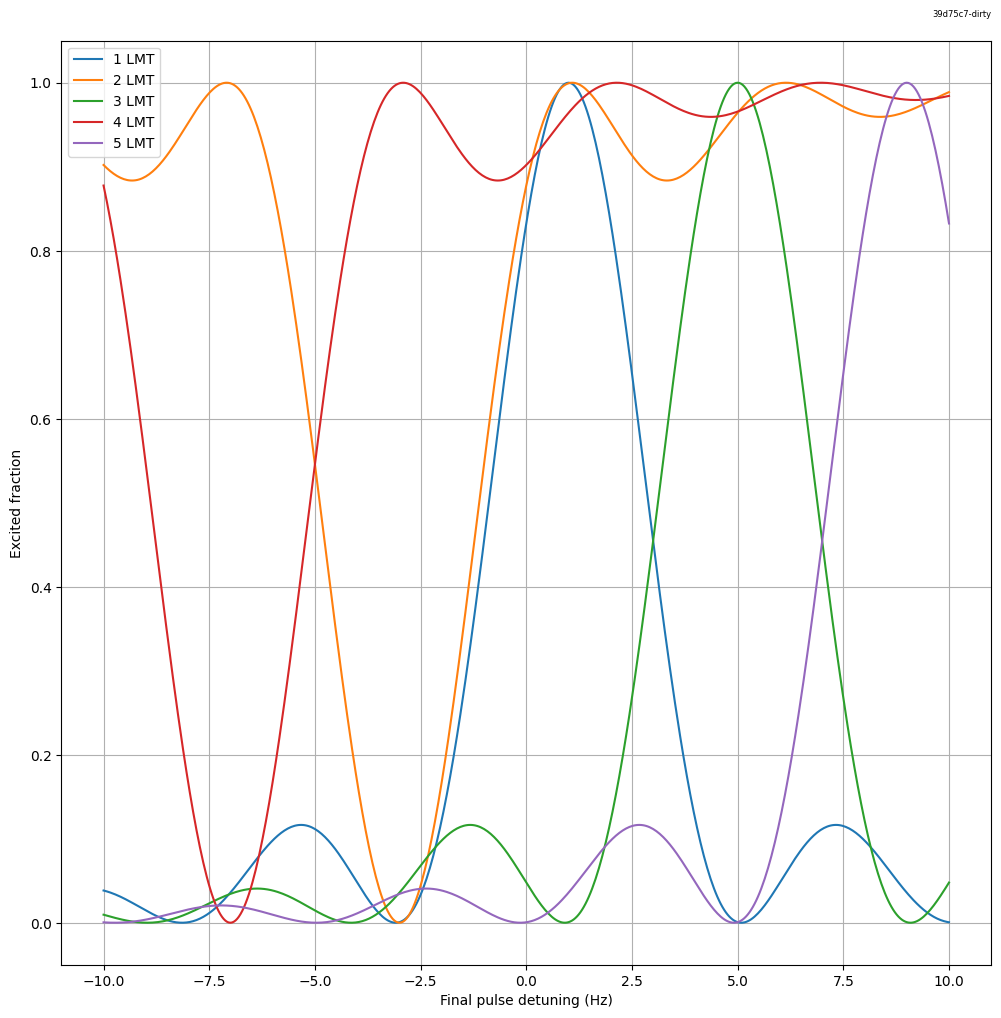

In [24]:
n_lmts = [1, 2, 3, 4, 5]
atom_radius = 0.0
beam_waist = 5e-3
initial_velocity_z = 0.0

final_detunings_hz = np.linspace(-10.0, 10.0, 501) * sim.RECOIL_FREQUENCY_HZ


def calc_resonant_detuning(i_lmt):
    return (2 * i_lmt + 1) * (-1) ** i_lmt * sim.RECOIL_FREQUENCY_HZ


plt.figure(figsize=(12, 12))
for n_lmt in n_lmts:
    sequence = []
    for i in range(n_lmt - 1):
        sequence.append(
            seq.Pulse(
                k=+1 if i % 2 == 0 else -1,
                detuning_hz=calc_resonant_detuning(i),
                phi=0.0,
                label=f"N={i}-TOP",
                rabi_frequency=sim.RABI_FREQ,
                duration=sim.T_PI,
            )
        )

    m, positions, velocities, amplitudes, internal_is_ground = sim.make_atom_states(
        position_x=atom_radius,
        position_y=0.0,
        position_z=0.0,
        initial_velocity_z=initial_velocity_z,
        c0=1.0,
        c1=0.0,
    )

    if sequence:
        result = seq.run_pulse_sequence_in_lab_frame(
            m,
            positions,
            velocities,
            amplitudes,
            internal_is_ground,
            pulse_sequence=sequence,
        )
        if result is None:
            raise RuntimeError("Atom was cleared out")
        m, positions, velocities, amplitudes, internal_is_ground, _, _ = result

    final_laser_direction = +1 if (n_lmt - 1) % 2 == 0 else -1

    excited_scan = []
    for final_detuning_hz in final_detunings_hz:
        m_trial = m.copy()
        positions_trial = positions.copy()
        velocities_trial = velocities.copy()
        amplitudes_trial = amplitudes.copy()
        internal_is_ground_trial = internal_is_ground.copy()

        final_pulse = seq.Pulse(
            k=final_laser_direction,
            detuning_hz=final_detuning_hz,
            phi=0.0,
            label="FINAL-TOP",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        )

        result_final = seq.run_pulse_sequence_in_lab_frame(
            m_trial,
            positions_trial,
            velocities_trial,
            amplitudes_trial,
            internal_is_ground_trial,
            pulse_sequence=[final_pulse],
        )

        if result_final is None:
            raise RuntimeError("Atom was cleared out by final pulse")

        (
            m_trial,
            positions_trial,
            velocities_trial,
            amplitudes_trial,
            internal_is_ground_trial,
            _,
            _,
        ) = result_final

        ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(
            m_trial, amplitudes_trial, internal_is_ground_trial
        )
        excited_scan.append(excited_prob / (ground_prob + excited_prob))

    plt.plot(
        final_detunings_hz / sim.RECOIL_FREQUENCY_HZ,
        excited_scan,
        label=f"{n_lmt} LMT",
    )


plt.xlabel("Final pulse detuning (Hz)")
plt.ylabel("Excited fraction")
plt.grid(True)

plt.legend()

# plt.xlim([-1000, 1000])

vs.tag_plot(small=True)

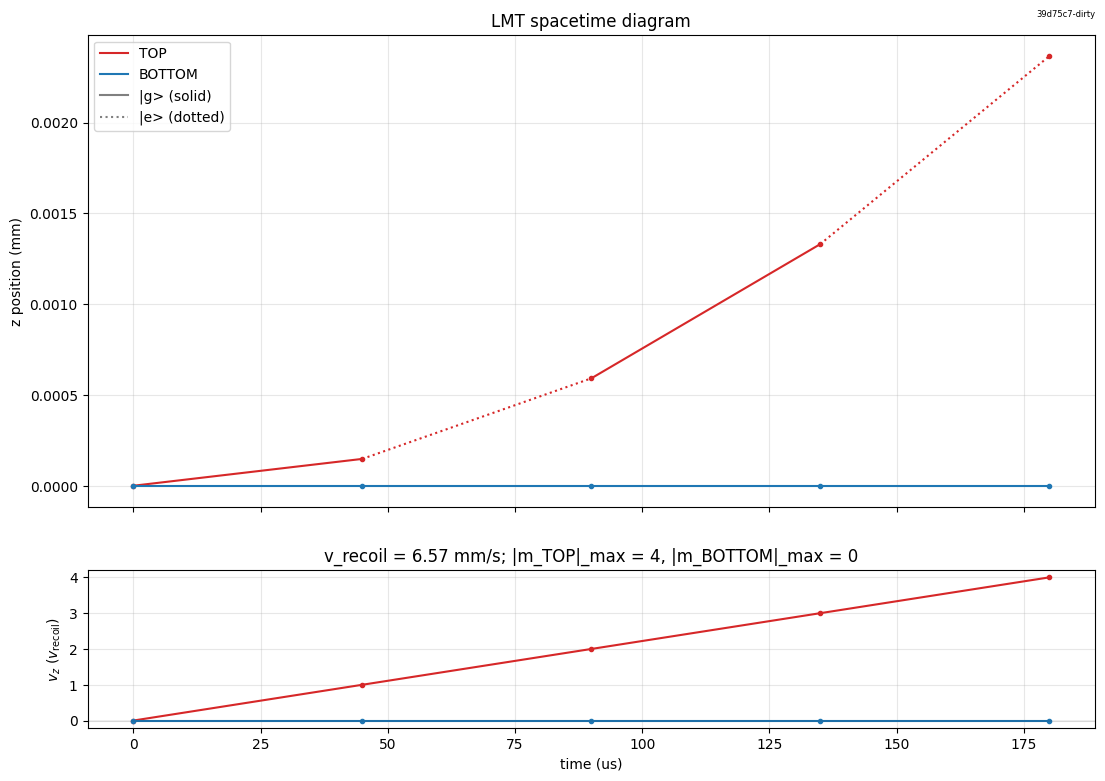

In [25]:
seq.compute_spacetime_trajectory(sequence, plot=True)

vs.tag_plot(small=True);

# Simple interferometry


ValueError: Pulse label must address exactly one cloud with '-TOP' or '-BOT': BEAM-SPLITTER

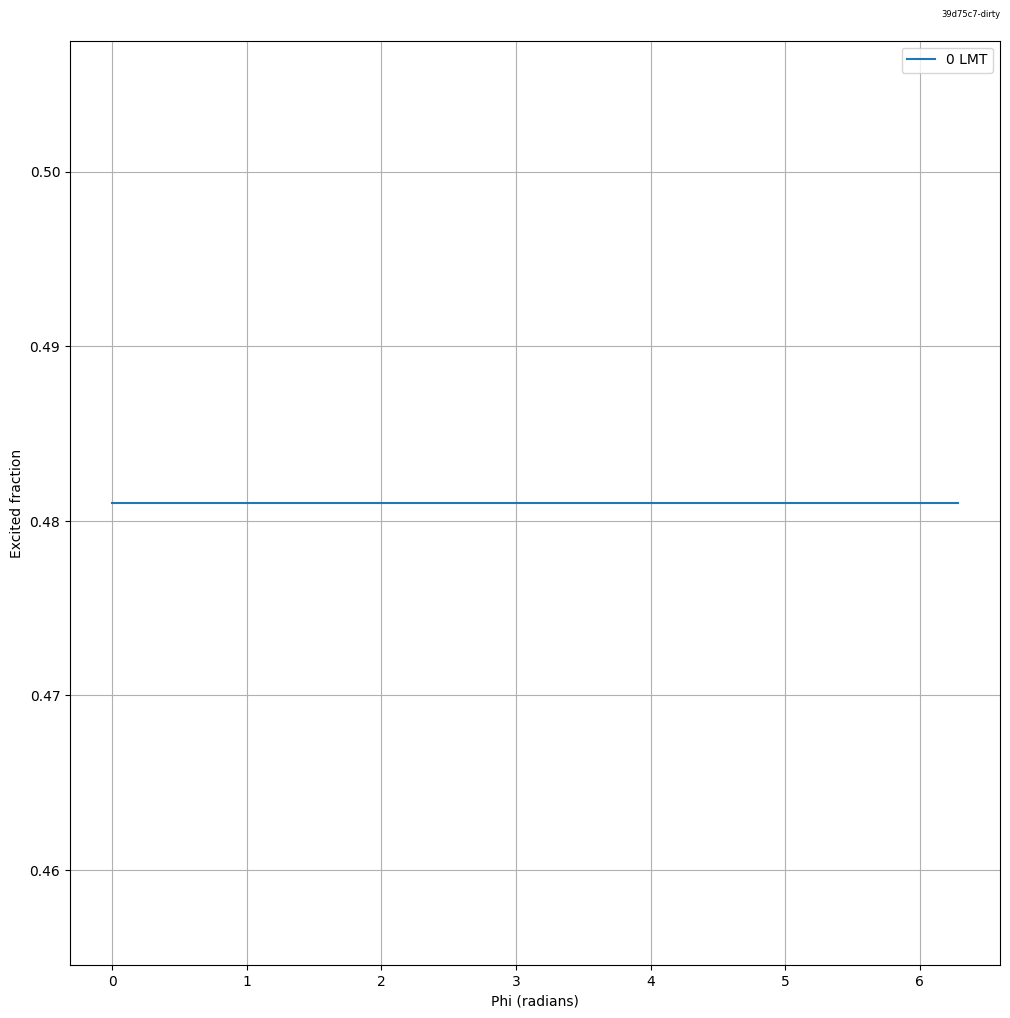

<Figure size 640x480 with 0 Axes>

In [30]:
n_lmts = [0]
atom_radius = 0.0
beam_waist = 5e-3
initial_velocity_z = 0.0
detuning_hz = 0

phis = np.linspace(0, 2*np.pi, 201)


plt.figure(figsize=(12, 12))
for n_lmt in n_lmts:
    excitation_fracs = []
    for phi in phis:
        sequence = []

        # Beam splitter
        sequence.append(
            seq.Pulse(
                k=+1,
                detuning_hz=detuning_hz,
                phi=0.0,
                label="BEAM-SPLITTER",
                rabi_frequency=sim.RABI_FREQ,
                duration=sim.T_PI/2,
            )
        )

        # Accelerating LMTs
        for i in range(1, n_lmt):
            sequence.append(
                seq.Pulse(  
                    k=1 if i % 2 == 0 else -1,
                    detuning_hz=calc_resonant_detuning(i) + detuning_hz,
                    phi=0.0,
                    label=f"N={i}-TOP",
                    rabi_frequency=sim.RABI_FREQ,
                    duration=sim.T_PI,
                )
            )
        
        # Decelerating LMTs
        for i in range(n_lmt - 1, 0, -1):
            sequence.append(
                seq.Pulse(  
                    k=1 if i % 2 == 0 else -1,
                    detuning_hz=calc_resonant_detuning(n_lmt - i) + detuning_hz,
                    phi=phi,
                    label=f"N={n_lmt - i}-TOP",
                    rabi_frequency=sim.RABI_FREQ,
                    duration=sim.T_PI,
                )
            )

        m, positions, velocities, amplitudes, internal_is_ground = sim.make_atom_states(
            position_x=atom_radius,
            position_y=0.0,
            position_z=0.0,
            initial_velocity_z=initial_velocity_z,
            c0=1.0,
            c1=0.0,
        )

        if sequence:
            result = seq.run_pulse_sequence_in_lab_frame(
                m,
                positions,
                velocities,
                amplitudes,
                internal_is_ground,
                pulse_sequence=sequence,
            )
            if result is None:
                raise RuntimeError("Atom was cleared out")
            m, positions, velocities, amplitudes, internal_is_ground, _, _ = result

        ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(
            m, amplitudes, internal_is_ground
        )
        excitation_fracs.append(excited_prob / (ground_prob + excited_prob))

    plt.plot(
        phis,
        excitation_fracs,
        label=f"{n_lmt} LMT",
    )


plt.xlabel("Phi (radians)")
plt.ylabel("Excited fraction")
plt.grid(True)

plt.legend()

# plt.xlim([-1000, 1000])

vs.tag_plot(small=True);


plt.figure()
seq.compute_spacetime_trajectory(sequence, plot=True)

vs.tag_plot(small=True);